# Retinal Images for Vessel Extraction
**Module:** CO4 - Imaging for the Life Science FS26

**Lecturers:** Dr. sc. ETH Andreas Hock and Dr. Norman Juchler

**Author:** Luana da Silva do Aido - dasillua@students.zhaw.ch

## 1. Introduction
The DRIVE (Digital Retinal Images for Vessel Extraction) dataset was used for this project (DRIVE - Grand Challenge, n.d).  It consists of 40 color fundus photographs of the human retina, acquired using a Canon CR5 non-mydriatic 3CCD camera with a 45° field of view. The images were captured as part of a diabetic retinopathy screening program in the Netherlands and have a resolution of 565×584 pixels in TIF format. The dataset is pre-split into 20 training and 20 test images, each accompanied by a binary field-of-view mask.

The retina is the only part of the human body where blood vessels can be observed non-invasively and in high resolution. Changes in the retinal vasculature, such as narrowing, leakage, or abnormal growth of vessels, are early indicators of serious systemic diseases. Diabetic retinopathy, for example, affects approximately one third of all diabetic patients and is one of the leading causes of blindness worldwide (Teo et al., 2021). 

Similarly, hypertension and glaucoma cause characteristic changes in the retinal vessel structure that can be detected before clinical symptoms appear (Patton et al., 2006).

Manual assessment of retinal images by ophthalmologists is time-consuming, subjective, and not scalable for large-scale population screening. Automated vessel segmentation addresses this by enabling fast, reproducible, and objective analysis of large image datasets. This is a critical step toward computer-aided diagnosis and early disease detection. 

### 1.1 Current Methods
Early approaches to retinal vessel segmentation relied on classical image processing techniques such as matched filter, morphological operations, and vessel-enhancement filter like the Frangi filter (Frangi et al., 1998). While these methods are fast and require no training data, they struggle with low contrasts, noise, and fine vessel structures.

With the rise of deep learning, convolutional neural networks (CNNs) have become the dominant approach, particularly U-Net architectures (Ronneberger et al., 2015). 

U-Net was originally developed for biomedical image segmentation and achieves Dice scores above 0.80 on the DRIVE dataset (Orlando et al., 2017). 

More recently, transformer-based architectures and hybrid CNN-transformer models have further improved performance by capturing long-range spatial dependencies in images.

### 1.2 Scope of this Work
The aim of this project is to explore and compare two fundamentally different approaches to retinal vessel segmentation. Firs a classical image processing method and secondly a machine learning method. Rather than aiming for the status quo performance, the focus lies on understanding the strengths and weaknesses of each approach on a small, well-defined dataset.

The DRIVE dataset provides an ideal benchmark for this purpose, as it is well-documented and publicly available. By manually segmenting a subset of images, a deeper understanding of what makes vessel segmentation challenging can be gained. 

This work demonstrates a complete segmentation pipeline: from raw retinal images though preprocessing, manual annotation, automatic segmentation, to quantitative evaluation. These insights gained here lay the groundwork for understanding more advanced methods such as deep learning-based segmentation.


### 1.3 Usage Rights
The DRIVE dataset is publicly available for research purposes at: https://drive.grand-challenge.org/DRIVE/
Usage rights have been verified, and the dataset is freely available for academic and non-commercial research.


## 2. Preprocessing
This section covers all preprocessing steps applied to the retinal images before automatic segmentation. It includes loading the images, extracting the green channel, applying contrast enhancement (CLAHE), normalizing the pixel values, and applying a retinal mask. Each step is explained and visualized. 

### 2.1 Imports
All required Pyhton libraries are imported here. This includes standard libraries for image processing, machine learning, numerical computation, and visualization. 


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import os
import pandas as pd
from PIL import Image
from skimage.filters import frangi, gaussian, sobel
from skimage.morphology import remove_small_objects, erosion, disk
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, jaccard_score
import warnings

warnings.filterwarnings('ignore')

### 2.2 Load Images
The images and manual segmentations are loaded from disk into Python dictionaries. Each dictionary maps the filename to the corresponding image array. Images are converted from BRG (OpenCV default) to RGB. Manual segmentations are loaded using PIL to correctly handle the TIF format. They were converted to binary masks where 0 = background (black) and 1 = vessels (white).

In [35]:
def load_images(folder_path):
    """
    Loads all TIF and PNG images from a folder and converts them from BGR to RGB.

    Args:
        folder_path (str): Path to the folder containing the images.

    Returns:
        dict: Filename as key, RGB image array as value.
    """
    images = {}
    for filename in sorted(os.listdir(folder_path)):
        if filename.endswith('.tif') or filename.endswith('.png'):
            img = cv.imread(os.path.join(folder_path, filename))
            images[filename] = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    return images


def load_segmentations(folder_path):
    """
    Loads manual segmentation masks and converts them to binary arrays.
    PIL is used instead of cv2 because it handles the TIF orientation 
    from Fiji correctly.

    Args:
        folder_path (str): Path to the folder containing the masks.

    Returns:
        dict: Filename as key, binary mask array (0 or 1) as value.
    """
    masks = {}
    for filename in sorted(os.listdir(folder_path)):
        if filename.endswith('.tif') or filename.endswith('.png'):
            img = np.array(Image.open(os.path.join(folder_path, filename)))
            if len(img.shape) == 3:
                img = img[:, :, 0]
            masks[filename] = (img > 127).astype(np.uint8)
    return masks


# Load images and segmentations
train_images = load_images('DRIVE/training/images/')
test_images = load_images('DRIVE/test/images')
manual_segs = load_segmentations('DRIVE/training/segmentation_images')
manual_segs_test = load_segmentations('DRIVE/test/segmentation_images')

print(f'Training images: {len(train_images)}')
print(f'Test images: {len(test_images)}')
print(f'Manual segmentations (training): {len(manual_segs)}')
print(f'Manual segmentations (test): {len(manual_segs_test)}')

Training images: 20
Test images: 10
Manual segmentations (training): 10
Manual segmentations (test): 10


20 training images and 20 test images were loaded successfully. 10 manual segmentations were created for each set, giving a total of 20 ground truth masks for evaluation. 

### 2.3 Preprocessing Pipeline
Each image is preprocessed through three steps: 

1. Extraction of the green channel, which provides the highest contrast for blood vessels
2. Application of CLAHE to enhance local contrast
3. Normalization to [0, 1]
4. Application of a binary retinal mask to the eyeball region only

From the RGB image, only the green channel is kept. This works because blood absorbs green light more than red or blue, so vessels appear darker in the green channel and stand out more clearly from the surrounding tissue. The image also becomes grayscale (one channel instead of three), which makes the next steps simpler.

CLAHE is used to make the image contrast better. Unlike regular contrast adjustment which works on the whole image at once, CLAHE splits the image into small regions and adjusts each one separately. This is helpful for retinal images because the brightness is not the same across the whole image. The settings `clipLimit=2.0` and `tileGridSize=(8,8)` work well for retinal images.

The pixel values are scaled from 0–255 to 0–1. This is a common step in image processing to make sure all values are in the same range, which helps the algorithms work more reliably.

The DRIVE dataset comes with mask files (GIF format) that mark which pixels are inside the eye. The mask is multiplied with the image, setting everything outside the eye to 0. This makes sure the segmentation only looks at the relevant area and does not accidentally detect vessels in the black corners.


In [36]:
def preprocess_image(img):
    """
    Prepares a retinal image for vessel segmentation by extracting the green 
    channel, enhancing local contrast with CLAHE, and normalizing to [0, 1].

    Args:
        img (np.ndarray): RGB image of shape (H, W, 3).

    Returns:
        np.ndarray: Grayscale image normalized to [0, 1].
    """
    green = img[:, :, 1]
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(green)
    return enhanced / 255.0


def apply_mask(img, mask_path):
    """
    Applies a retinal mask to an image to remove everything outside the eyeball.
    The mask is loaded from a GIF file and multiplied with the image.

    Args:
        img (np.ndarray): Grayscale image normalized to [0, 1].
        mask_path (str): Path to the GIF mask file.

    Returns:
        np.ndarray: Image with all pixels outside the retinal region set to 0.
    """
    mask = np.array(Image.open(mask_path)) / 255.0
    return img * mask


# Keep only the images that have a manual segmentation
train_images_filtered = {name: train_images[name] for name in manual_segs.keys()}
test_images_filtered = {name: test_images[name] for name in manual_segs_test.keys() if name in test_images}

# Preprocess and mask training images
train_preprocessed_filtered = {name: preprocess_image(img) for name, img in train_images_filtered.items()}
train_masked_filtered = {}
for name in manual_segs.keys():
    mask_path = os.path.join('DRIVE/training/mask', name.replace('.tif', '_mask.gif'))
    train_masked_filtered[name] = apply_mask(train_preprocessed_filtered[name], mask_path)

# Preprocess and mask test images
test_preprocessed_filtered = {name: preprocess_image(img) for name, img in test_images_filtered.items()}
test_masked_filtered = {}
for name in manual_segs_test.keys():
    mask_path = os.path.join('DRIVE/test/mask', name.replace('.tif', '_mask.gif'))
    test_masked_filtered[name] = apply_mask(test_preprocessed_filtered[name], mask_path)

first_name = list(train_masked_filtered.keys())[0]
print(f'Training preprocessed: {len(train_masked_filtered)} images')
print(f'Test preprocessed: {len(test_masked_filtered)} images')

Training preprocessed: 10 images
Test preprocessed: 10 images


All 10 training and 10 test images were successfully preprocessed. Each image was converted to a normalized grayscale image, and the retinal mask was applied to restrict the region of interests.


### 2.3 Visualization
The following plots visualize the effect of each preprocessing step on an example image. The first plot shows the original image, the preprocessed (CLAHE + green channel) image, and the masked result side by side. The second plot highlights what the retinal mask removes by showing the difference between the preprocessed and masked image.

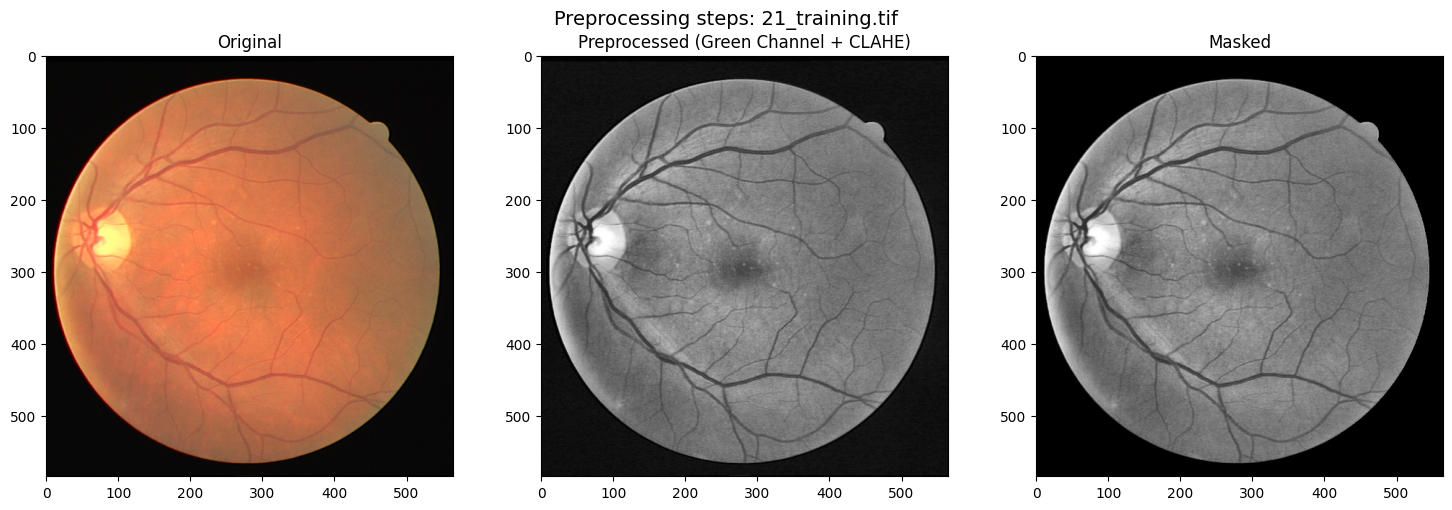

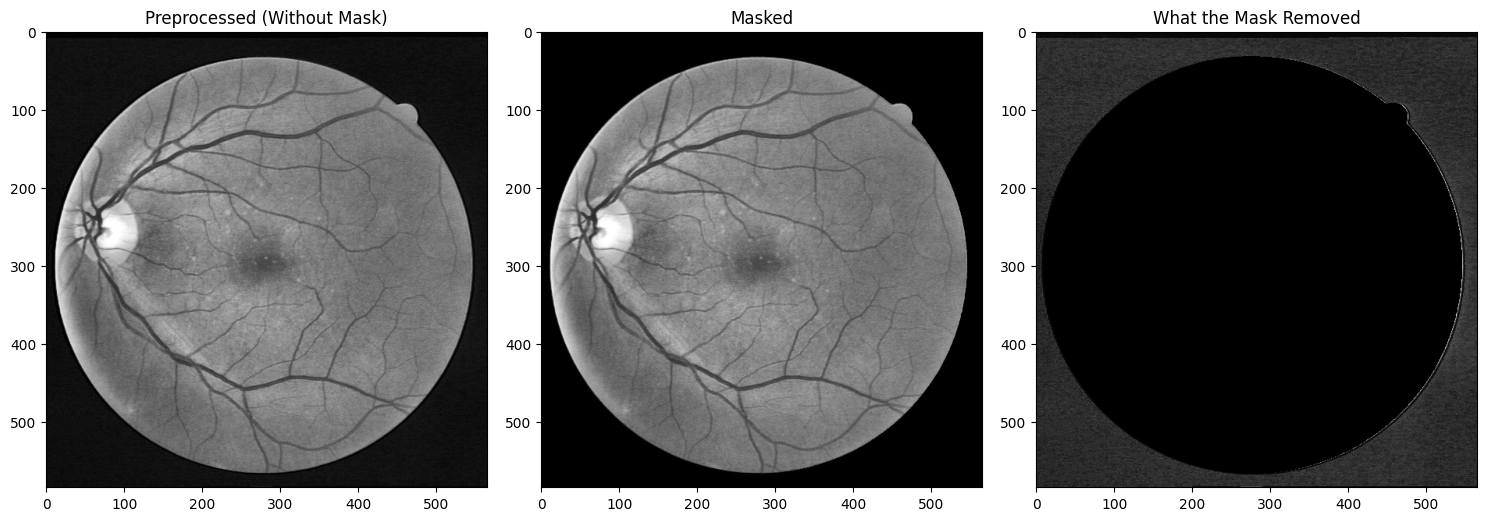

In [37]:
# Plot 1: show the three preprocessing steps side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(train_images_filtered[first_name])
axes[0].set_title('Original')

axes[1].imshow(train_preprocessed_filtered[first_name], cmap='gray')
axes[1].set_title('Preprocessed (Green Channel + CLAHE)')

axes[2].imshow(train_masked_filtered[first_name], cmap='gray')
axes[2].set_title('Masked')

plt.suptitle(f'Preprocessing steps: {first_name}', fontsize=14)
plt.tight_layout()
plt.savefig('DRIVE/training/preprocessing_example.png', dpi=150)
plt.show()

# Plot 2: show what the mask actually removed
diff = train_preprocessed_filtered[first_name] - train_masked_filtered[first_name]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(train_preprocessed_filtered[first_name], cmap='gray')
axes[0].set_title('Preprocessed (Without Mask)')

axes[1].imshow(train_masked_filtered[first_name], cmap='gray')
axes[1].set_title('Masked')

axes[2].imshow(diff, cmap='gray')
axes[2].set_title('What the Mask Removed')

plt.tight_layout()
plt.show()

The preprocessing clearly enhances vessel visibility. The green channel combined with CLAHE increases the local contrast of blood vessels against the background tissue. Although the mask effect appears minimal visually, since the image background is already nearly black after preprocessing, it remains an important step. It explicitly guarantees that no pixels outside the retinal region are processed, preventing potential false vessel detections at the image borders during automatic segmentation.


## 3. Manual Segmentation
This section describes the manual segmentation process. It explains which tools was used, how the segmentation was performed step by step, how many images were annotated, and what challenges were encountered. Example images of the manual segmentation are shown.

### 3.1 Workflow
Fiji (ImageJ) was used for manual segmentation. Each image was opened in Fiji and converted to 8-bit grayscale. The brightness and contrast were individually adjusted to make the vessels more visible. The vessels were then traced manually using the Pencil tool. Afterwards, the image was binarized using the Threshold function and saves as a TIF file. Each image took approximately 15-20 minutes to segment. 

In total, 10 training images were segmented to serve as ground truth for training the Random Forest, and 10 test images were segmented separately to use as ground truth for the final evaluation.

The manual segmentation process came with several challenges. Some images had lower contrast, making it harder to tell vessels apart from the surrounding tissue. Fine and thin vessels were particularly difficult to trace accurately with the pencil tool. The optic disc (the bright circular region where the nerve enters the eye) was sometimes accidentally included in the mask because it is hard to distinguish from vessel tissue. Finally, manual segmentation is always somewhat subjective, meaning that a different person tracing the same image might produce slightly different results. The final binary masks have white pixels (255) for vessels and black (0) for background.

### 3.2 Visualization
The following plot shows an example of a manually segmented image next to its original. This illustrates what the ground truth masks look like and what level of detail was captured during manual annotation.


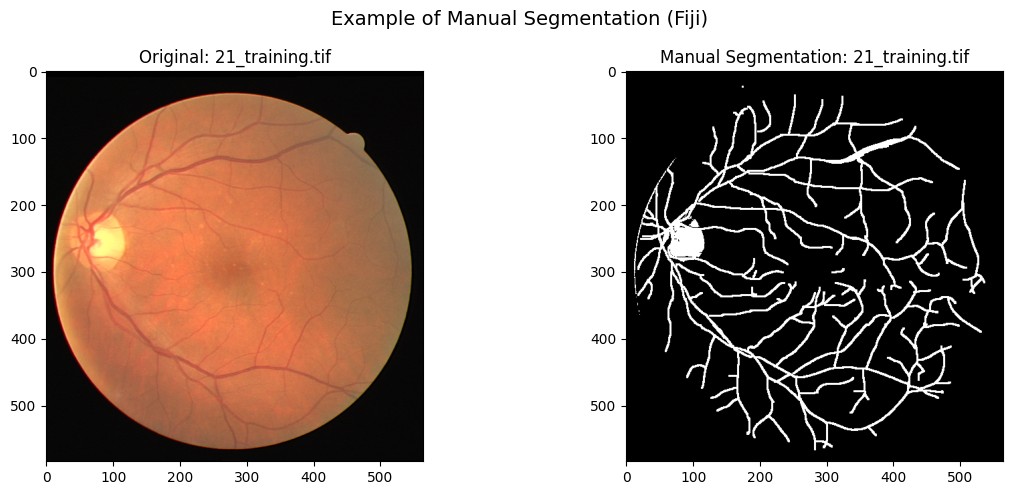

In [38]:
# Show example of manual segmentation
first_seg_name = list(manual_segs.keys())[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(train_images_filtered[first_seg_name])
axes[0].set_title(f'Original: {first_seg_name}')
axes[1].imshow(manual_segs[first_seg_name], cmap='gray')
axes[1].set_title(f'Manual Segmentation: {first_seg_name}')
plt.suptitle('Example of Manual Segmentation (Fiji)', fontsize=14)
plt.tight_layout()
plt.show()

The resulting binary masks have white pixels for vessels and black for background. The major vessels are clearly visible and well-traced. As visible in the example above, Finer capillaries are partially captured but with lower accuracy. Additionally, the optic disc appears as a bright filled region, and a faint ring is visible at the edge of the eyeball. Both are artifacts caused by high light intensity in these areas, witch the threshold could not distinguish from actual vessel tissue.

## 4. Automatic Segmentation
This section implements two automatic segmentation methods: the Frangi filter, a classical image processing approach, and a Random Forest classifier, a machine learning approach. For each method the implementation is described, the result are visualized, and the limitations are discussed. 

### 4.1 Classical Method: Frangi Filter
The Frangi filter was chosen as the classical segmentation approach because it was specifically developed for the enhancement and detection of tubular structures such as blood vessels (Frangi et al., 1998). It works by analyzing the local curvature of the image at each pixel using the Hessian matrix (second-order derivatives). At each scale, the eigenvalues of the Hessian matrix are used to distinguish vessel-like structures from background noise and blob-like regions. Pixels where the curvature is consistent with a tube-like structure receive a high response value. The filter operates at multiple scales simultaneously, making it effective for detecting both thick and thin vessels (Frangi et al., 1998). It has been widely used as a baseline method for retinal vessel segmentation and remains a standard reference in the field (Orlando et al., 2017).

The filter requires no training data and can be directly applied to any preprocessed image, making it a fast and scalable approach. After computing the vessel probability map, the result is binarized using a fixed threshold (0.05), small noise objects are removed, and the retinal mask is applied with additional erosion to eliminate ring artifacts at the border.


Frangi segmentation done!


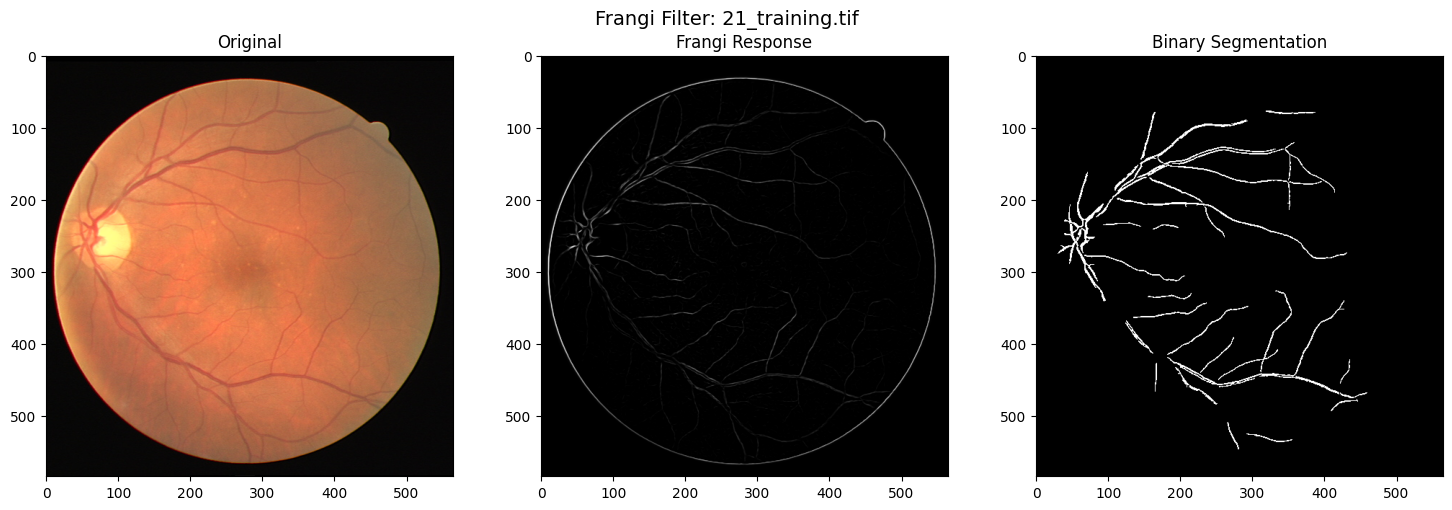

In [39]:
def frangi_segmentation(img, mask_path, threshold=0.05):
    """
    Detects blood vessels using the Frangi filter. The filter assigns each pixel
    a score based on how much it looks like part of a tubular structure. The result
    is binarized, small noise objects are removed, and an eroded mask is applied
    to avoid a ring artifact at the border of the eyeball.

    Args:
        img (np.ndarray): Grayscale image normalized to [0, 1].
        mask_path (str): Path to the GIF mask file.
        threshold (float): Cutoff value to decide vessel vs background.

    Returns:
        tuple: Binary segmentation mask and raw Frangi response map.
    """
    # Run the Frangi filter and normalize the response to [0, 1]
    response = frangi(img)
    response = response / response.max()

    # Turn the probability map into a binary mask
    binary = (response > threshold).astype(bool)

    # Remove small isolated noise blobs
    binary = remove_small_objects(binary, min_size=50)

    # Shrink the retinal mask slightly to remove the bright border ring
    mask = np.array(Image.open(mask_path)) / 255.0
    mask = erosion(mask, disk(20))
    binary = binary * mask

    return binary.astype(np.uint8), response


# Apply Frangi to all training images
train_frangi_filtered = {}
for name in manual_segs.keys():
    mask_path = os.path.join('DRIVE/training/mask', name.replace('.tif', '_mask.gif'))
    train_frangi_filtered[name], _ = frangi_segmentation(train_masked_filtered[name], mask_path)

# Apply Frangi to all test images
test_frangi_filtered = {}
for name in manual_segs_test.keys():
    mask_path = os.path.join('DRIVE/test/mask', name.replace('.tif', '_mask.gif'))
    test_frangi_filtered[name], _ = frangi_segmentation(test_masked_filtered[name], mask_path)

print('Frangi segmentation done!')

# Visualize the result on the first training image
_, enhanced = frangi_segmentation(
    train_masked_filtered[first_name],
    os.path.join('DRIVE/training/mask', first_name.replace('.tif', '_mask.gif'))
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(train_images_filtered[first_name])
axes[0].set_title('Original')
axes[1].imshow(enhanced, cmap='gray')
axes[1].set_title('Frangi Response')
axes[2].imshow(train_frangi_filtered[first_name], cmap='gray')
axes[2].set_title('Binary Segmentation')
plt.suptitle(f'Frangi Filter: {first_name}', fontsize=14)
plt.tight_layout()
plt.show()

The Frangi filter successfully detects the main vessel branches visible in the retinal image. The vessel probability map (middle image) shows high response values along elongated structures, which are then binarized into a clean segmentation mask. However, fine capillaries and vessels with low contrast are often missed, and the method is sensitive to the choice of threshold.

### 4.2 ML Method: Random Forest
A Random Forest classifier was chosen as the machine learning approach for this project. Random Forests are an ensemble method that combines multiple decision trees, each trained on a random subset of the data, and combines their predictions by majority vote (Breiman, 2001). They are well suited for pixel-wise classification tasks in medical image analysis because they handle high-dimensional feature spaces well, are robust to noise, and do not require large amounts of training data compared to deep learning methods (Criminisi et al., 2012). Several studies have successfully applied Random Forests to retinal vessel segmentation, showing competitive results with classical methods while being more adaptable to the data (Lupascu et al., 2010).

The classifier is trained on pixel-wise features extracted from the manually segmented training images. For each pixel, a feature vector is computed, and the classifier decides whether the pixel belongs to a vessel or not. By learning from the manual annotations, the Random Forest can adapt to the specific appearance of vessels in this dataset.

**Features per pixel:**
1. Raw intensity value
2. Gaussian blur at scales σ = 1, 2, 4 (captures multi-scale structure)
3. Sobel edge response (detects vessel boundaries)
4. Frangi response (vessel probability from classical method)

The following code extracts features, trains the classifier on the 10 training images, and applies it to generate segmentation masks. The model is then evaluated on the 10 unseen test images for a fair assessment.


Total training pixels: 3299600, Features per pixel: 6
Training Random Forest...
Done!


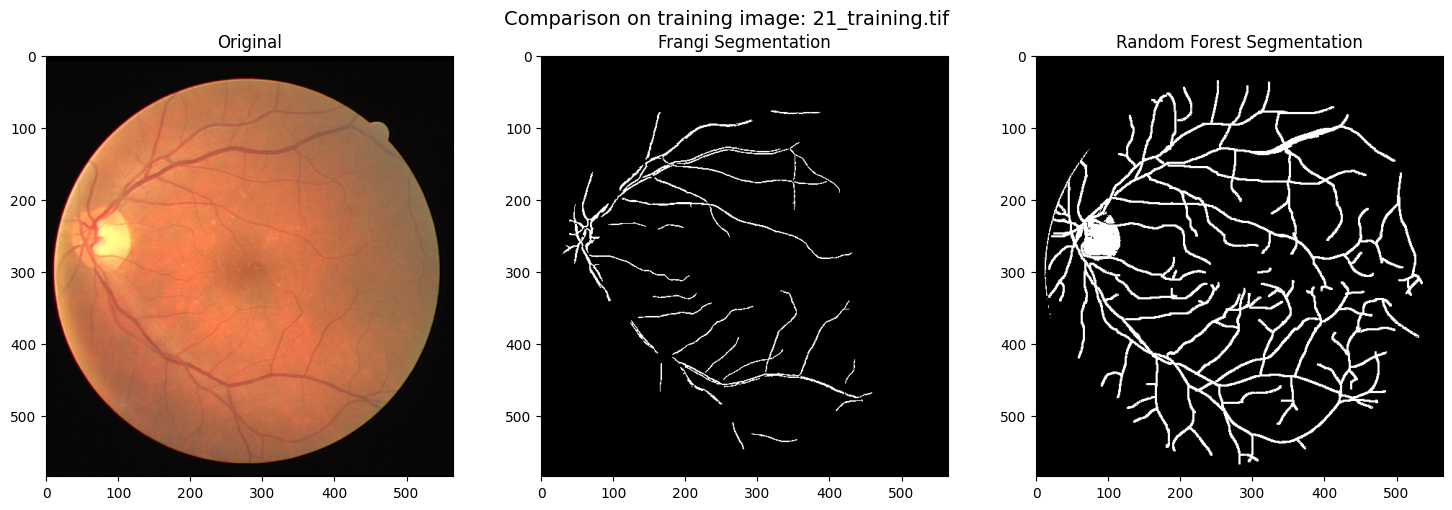

In [40]:
def extract_features(img):
    """
    Builds a feature vector for every pixel in the image.
    Each pixel is described by its raw intensity, blurred versions at three
    different scales, its edge strength (Sobel), and its Frangi vessel score.

    Args:
        img (np.ndarray): Grayscale image normalized to [0, 1].

    Returns:
        np.ndarray: Feature matrix of shape (n_pixels, 6).
    """
    features = []

    # Raw pixel intensity
    features.append(img.flatten())

    # Blurred versions at different scales to capture local context
    for sigma in [1, 2, 4]:
        features.append(gaussian(img, sigma=sigma).flatten())

    # Edge strength — helps detect vessel boundaries
    features.append(sobel(img).flatten())

    # Frangi vessel probability as an additional feature
    frangi_response = frangi(img)
    frangi_response = frangi_response / (frangi_response.max() + 1e-8)
    features.append(frangi_response.flatten())

    return np.stack(features, axis=1)


def prepare_training_data(masked_images, manual_segs):
    """
    Collects features and labels from all training images to build the
    dataset for the Random Forest. Each pixel becomes one training sample.

    Args:
        masked_images (dict): Preprocessed and masked images.
        manual_segs (dict): Binary manual segmentation masks (ground truth).

    Returns:
        tuple: Feature matrix X and label vector y.
    """
    X_list, y_list = [], []
    for name in manual_segs.keys():
        X_list.append(extract_features(masked_images[name]))
        y_list.append(manual_segs[name].flatten())

    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    print(f'Total training pixels: {X.shape[0]}, Features per pixel: {X.shape[1]}')
    return X, y


def train_random_forest(X_train, y_train):
    """
    Trains a Random Forest classifier on the pixel features.
    Uses 50 trees and all available CPU cores to speed up training.

    Args:
        X_train (np.ndarray): Feature matrix of shape (n_pixels, n_features).
        y_train (np.ndarray): Binary labels (0 = background, 1 = vessel).

    Returns:
        RandomForestClassifier: Trained model.
    """
    print('Training Random Forest...')
    rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    print('Done!')
    return rf


def predict_vessels(rf_model, img):
    """
    Uses the trained Random Forest to predict which pixels are vessels.

    Args:
        rf_model (RandomForestClassifier): Trained classifier.
        img (np.ndarray): Preprocessed and masked image normalized to [0, 1].

    Returns:
        np.ndarray: Binary segmentation mask of shape (H, W).
    """
    return rf_model.predict(extract_features(img)).reshape(img.shape)


# Train the model on the 10 annotated training images
X_train, y_train = prepare_training_data(train_masked_filtered, manual_segs)
rf_model = train_random_forest(X_train, y_train)

# Compare Frangi and Random Forest on the first training image
rf_binary = predict_vessels(rf_model, train_masked_filtered[first_name])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(train_images_filtered[first_name])
axes[0].set_title('Original')
axes[1].imshow(train_frangi_filtered[first_name], cmap='gray')
axes[1].set_title('Frangi Segmentation')
axes[2].imshow(rf_binary, cmap='gray')
axes[2].set_title('Random Forest Segmentation')
plt.suptitle(f'Comparison on training image: {first_name}', fontsize=14)
plt.tight_layout()
plt.show()

The Random Forest was trained on approximately 3.3 million pixels from 10 images, each described by 6 features. Compared to the Frangi filter, the Random Forest detects more vessels including finer branches. However, it also tends to produce more false positives, particularly around the optic disc. The model was trained exclusively on training images and will be evaluated on unseen test images to avoid overfitting bias.

The following code saves the automatic segmentation masks for both methods as PNG files. The masks are stored in the same binary format as the manual segmentations (0 = background, 255 = vessel), making them directly comparable and ready for further use.


In [41]:
os.makedirs('DRIVE/training/auto_segmentation_frangi', exist_ok=True)
os.makedirs('DRIVE/training/auto_segmentation_rf', exist_ok=True)

for name in manual_segs.keys():
    base_name = name.replace('.tif', '.png')
    
    # Save Frangi mask
    frangi_mask = (train_frangi_filtered[name] * 255).astype(np.uint8)
    cv.imwrite(f'DRIVE/training/auto_segmentation_frangi/{base_name}', frangi_mask)
    
    # Save Random Forest mask
    rf_mask = (predict_vessels(rf_model, train_masked_filtered[name]) * 255).astype(np.uint8)
    cv.imwrite(f'DRIVE/training/auto_segmentation_rf/{base_name}', rf_mask)

print('All training-automatic segmentation masks saved!')

os.makedirs('DRIVE/test/auto_segmentation_frangi', exist_ok=True)
os.makedirs('DRIVE/test/auto_segmentation_rf', exist_ok=True)

for name in manual_segs_test.keys():
    base_name = name.replace('.tif', '.png')
    
    # Save Frangi mask
    frangi_mask = (test_frangi_filtered[name] * 255).astype(np.uint8)
    cv.imwrite(f'DRIVE/test/auto_segmentation_frangi/{base_name}', frangi_mask)
    
    # Save Random Forest mask
    rf_mask = (predict_vessels(rf_model, test_masked_filtered[name]) * 255).astype(np.uint8)
    cv.imwrite(f'DRIVE/test/auto_segmentation_rf/{base_name}', rf_mask)

print('All test-automatic segmentation masks saved!')

All training-automatic segmentation masks saved!
All test-automatic segmentation masks saved!



## 5. Evaluation
This section evaluates how well the two automatic segmentation methods perform compared to the manual ground truth. For each of the 10 test images, the predicted segmentation mask is compared pixel-by-pixel against the manually created mask. The Dice score is used as the main metric, as it is specifically suited for binary segmentation tasks and directly measures the overlap between the predicted and the ground truth mask. The Jaccard score is computed as an additional metric. Results are presented both as a detailed table per image and as a bar chart showing the mean performance of each method across all test images. Overlap visualizations are generated to provide a qualitative view of where each method succeeds and where it fails.

### 5.1 Metrics

Dice Score (F1 Score) is used as the main evaluation metric for binary segmentation:

$$\text{Dice} = \frac{2 \cdot |\text{Predicted} \cap \text{Ground Truth}|}{|\text{Predicted}| + |\text{Ground Truth}|}$$

A Dice score of 1.0 means perfect overlap, 0.0 means no overlap.


Jaccard Score (IoU) is computed as an additional metric:

$$\text{Jaccard} = \frac{|\text{Predicted} \cap \text{Ground Truth}|}{|\text{Predicted} \cup \text{Ground Truth}|}$$

Both methods are evaluated on the 10 unseen test images to ensure fair comparison. The Random Forest was only trained on training images and has never seen the test images before.

The following code computes Dice and Jaccard scores for both methods on all 10 test images, then displays the results as a table including mean and standard deviation.



In [42]:
def evaluate_segmentation(predicted, ground_truth):
    """
    Compares a predicted segmentation mask against the manual ground truth
    by computing the Dice (F1) and Jaccard (IoU) scores pixel-wise.

    Args:
        predicted (np.ndarray): Binary predicted mask.
        ground_truth (np.ndarray): Binary ground truth mask.

    Returns:
        dict: Dice and Jaccard scores.
    """
    pred_flat = predicted.flatten()
    gt_flat = ground_truth.flatten()
    return {
        'dice': f1_score(gt_flat, pred_flat, zero_division=0),
        'jaccard': jaccard_score(gt_flat, pred_flat, zero_division=0)
    }


# Compute Dice and Jaccard scores for both methods on all 10 test images
test_results = []
for name in manual_segs_test.keys():
    gt = manual_segs_test[name]
    frangi_scores = evaluate_segmentation(test_frangi_filtered[name], gt)
    rf_scores = evaluate_segmentation(predict_vessels(rf_model, test_masked_filtered[name]), gt)

    test_results.append({
        'Image': name.replace('_test.tif', ''),
        'Frangi Dice': round(frangi_scores['dice'], 3),
        'Frangi Jaccard': round(frangi_scores['jaccard'], 3),
        'RF Dice': round(rf_scores['dice'], 3),
        'RF Jaccard': round(rf_scores['jaccard'], 3),
    })

df_test = pd.DataFrame(test_results)

# Add mean and standard deviation rows at the bottom
summary_rows = pd.DataFrame([
    {
        'Image': 'MEAN',
        'Frangi Dice': round(df_test['Frangi Dice'].mean(), 3),
        'Frangi Jaccard': round(df_test['Frangi Jaccard'].mean(), 3),
        'RF Dice': round(df_test['RF Dice'].mean(), 3),
        'RF Jaccard': round(df_test['RF Jaccard'].mean(), 3),
    },
    {
        'Image': 'STD',
        'Frangi Dice': round(df_test['Frangi Dice'].std(), 3),
        'Frangi Jaccard': round(df_test['Frangi Jaccard'].std(), 3),
        'RF Dice': round(df_test['RF Dice'].std(), 3),
        'RF Jaccard': round(df_test['RF Jaccard'].std(), 3),
    }
])

df_display = pd.concat([df_test, summary_rows], ignore_index=True)
print(df_display.to_string(index=False))

Image  Frangi Dice  Frangi Jaccard  RF Dice  RF Jaccard
   01        0.399           0.249    0.545       0.374
   02        0.478           0.314    0.566       0.394
   04        0.182           0.100    0.551       0.380
   05        0.427           0.272    0.518       0.349
   06        0.254           0.146    0.524       0.355
   09        0.276           0.160    0.501       0.334
   12        0.140           0.075    0.497       0.330
   15        0.403           0.252    0.493       0.327
   17        0.183           0.101    0.478       0.314
   18        0.315           0.187    0.551       0.380
 MEAN        0.306           0.186    0.522       0.354
  STD        0.117           0.083    0.030       0.027


### 5.2 Statistical Visualization

The following table shows the Dice and Jaccard scores for each individual test image, along with the mean and standard deviation across all 10 images.

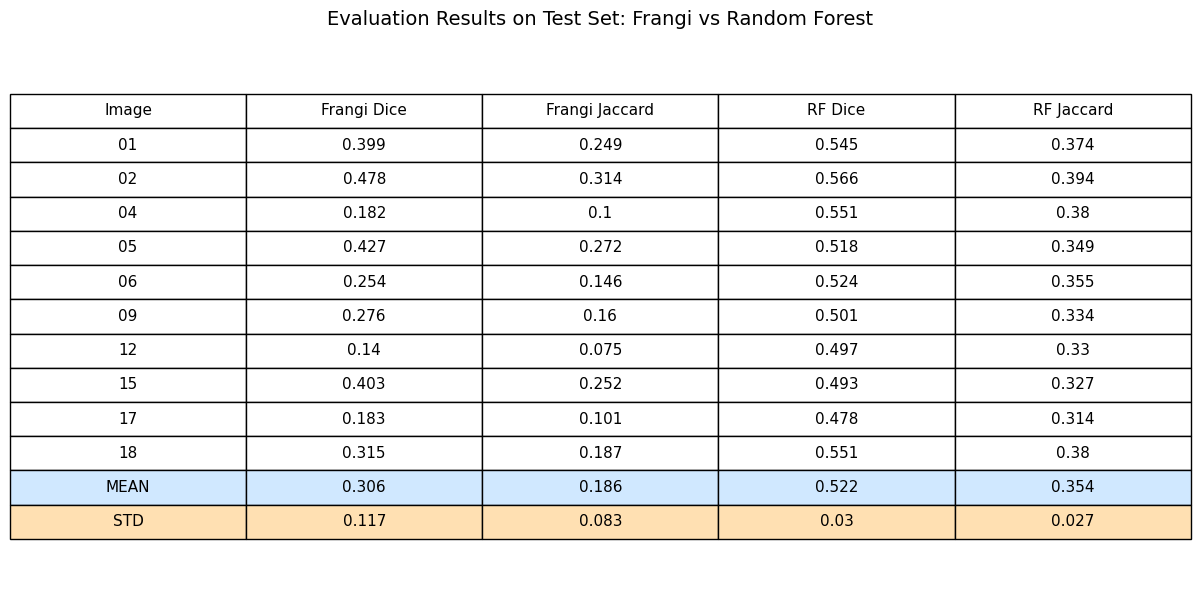

In [43]:
# Draw the results as a formatted table
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

table = ax.table(
    cellText=df_display.values,
    colLabels=df_display.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Highlight the mean row in blue and the std row in orange
for j in range(len(df_display.columns)):
    table[len(df_test) + 1, j].set_facecolor('#d0e8ff')
    table[len(df_test) + 2, j].set_facecolor('#ffe0b2')

plt.title('Evaluation Results on Test Set: Frangi vs Random Forest', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('DRIVE/test/evaluation_table.png', dpi=150, bbox_inches='tight')
plt.show()

The table lists the Dice and Jaccard scores for each of the 10 test images separately, allowing a detailed comparison between the two methods for every individual image. The Frangi Dice scores range from 0.140 to 0.478, while the Random Forest Dice scores are more clustered, ranging from 0.478 to 0.566. The mean row (highlighted in blue) shows the average performance across all images, and the STD row (highlighted in orange) shows how much the scores vary between images.

The bar chart below compares the mean Dice scores of both methods. The error bars show the standard deviation, giving an indication of how consistent each method performs across different images.

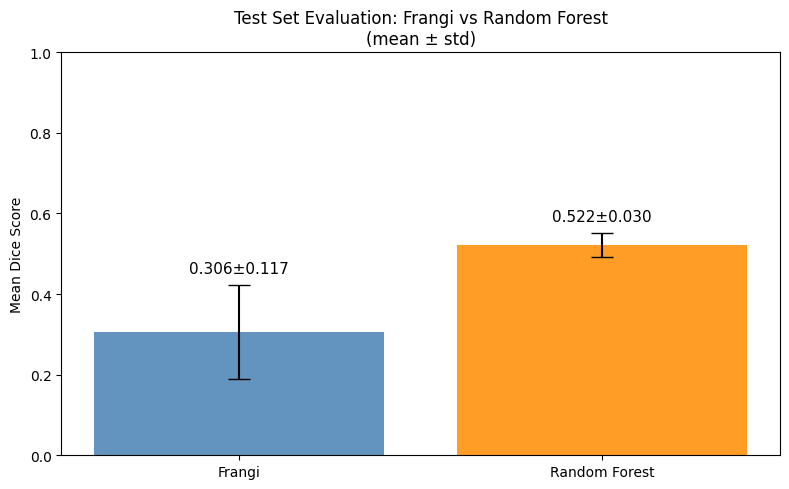

In [44]:
# Bar chart comparing mean Dice scores with standard deviation as error bars
methods = ['Frangi', 'Random Forest']
means = [df_test['Frangi Dice'].mean(), df_test['RF Dice'].mean()]
stds = [df_test['Frangi Dice'].std(), df_test['RF Dice'].std()]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(methods, means, yerr=stds, capsize=8,
              color=['steelblue', 'darkorange'], alpha=0.85)

ax.set_ylim(0, 1)
ax.set_ylabel('Mean Dice Score')
ax.set_title('Test Set Evaluation: Frangi vs Random Forest\n(mean ± std)')

# Add the exact values above each bar
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.03,
            f'{mean:.3f}±{std:.3f}',
            ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('DRIVE/test/evaluation_barchart.png', dpi=150)
plt.show()

The bar chart shows two bars, one for the Frangi filter (blue) and one for the Random Forest (orange). The Frangi bar reaches a height of 0.306 and has a long error bar extending both above and below, indicating a large spread in scores. The Random Forest bar is noticeably taller at 0.522 and has a much shorter error bar, showing that the scores are closer together across the different images.

### 5.3 Overlap Visualization

To better understand where each method succeeds and fails, overlap images are generated for all 10 test images. Simply looking at Dice scores does not reveal which parts of the image are correctly detected and which are missed. The overlap visualization makes this visible at a glance. Each image shows four panels: the original, the manual segmentation (ground truth), the automatic segmentation, and a color-coded overlap where green = True Positive (correctly detected vessel), red = False Negative (missed vessel), blue = False Positive (incorrectly detected as vessel). This allows a qualitative comparison of both methods beyond the numerical scores.

In [45]:
# Create output folders if they don't exist yet
os.makedirs('DRIVE/test/overlap_frangi', exist_ok=True)
os.makedirs('DRIVE/test/overlap_rf', exist_ok=True)


def save_overlap(original, manual, auto, title, save_path):
    """
    Creates and saves a four-panel overlap image showing where the automatic
    segmentation agrees or disagrees with the manual ground truth.
    Green = correctly detected vessel (TP), Red = missed vessel (FN),
    Blue = falsely detected as vessel (FP).

    Args:
        original (np.ndarray): Original RGB image.
        manual (np.ndarray): Binary manual segmentation mask.
        auto (np.ndarray): Binary automatic segmentation mask.
        title (str): Method name shown in the plot title.
        save_path (str): Where to save the figure.

    Returns:
        None
    """
    # Build the color-coded overlap image
    overlap = np.zeros((*manual.shape, 3), dtype=np.float32)
    overlap[..., 1] = ((manual == 1) & (auto == 1)).astype(float)  # Green = TP
    overlap[..., 0] = ((manual == 1) & (auto == 0)).astype(float)  # Red   = FN
    overlap[..., 2] = ((manual == 0) & (auto == 1)).astype(float)  # Blue  = FP

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(original)
    axes[0].set_title('Original')
    axes[1].imshow(manual, cmap='gray')
    axes[1].set_title('Manual Segmentation (Ground Truth)')
    axes[2].imshow(auto, cmap='gray')
    axes[2].set_title(f'Automatic Segmentation\n{title}')
    axes[3].imshow(overlap)
    axes[3].set_title('Overlap\nGreen=TP | Red=FN | Blue=FP')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()


# Generate and save overlap images for all 10 test images
for name in manual_segs_test.keys():
    base_name = name.replace('.tif', '.png')

    save_overlap(
        test_images_filtered[name], manual_segs_test[name],
        test_frangi_filtered[name], 'Frangi',
        f'DRIVE/test/overlap_frangi/{base_name}'
    )

    save_overlap(
        test_images_filtered[name], manual_segs_test[name],
        predict_vessels(rf_model, test_masked_filtered[name]), 'Random Forest',
        f'DRIVE/test/overlap_rf/{base_name}'
    )

print('All overlap images saved!')

All overlap images saved!


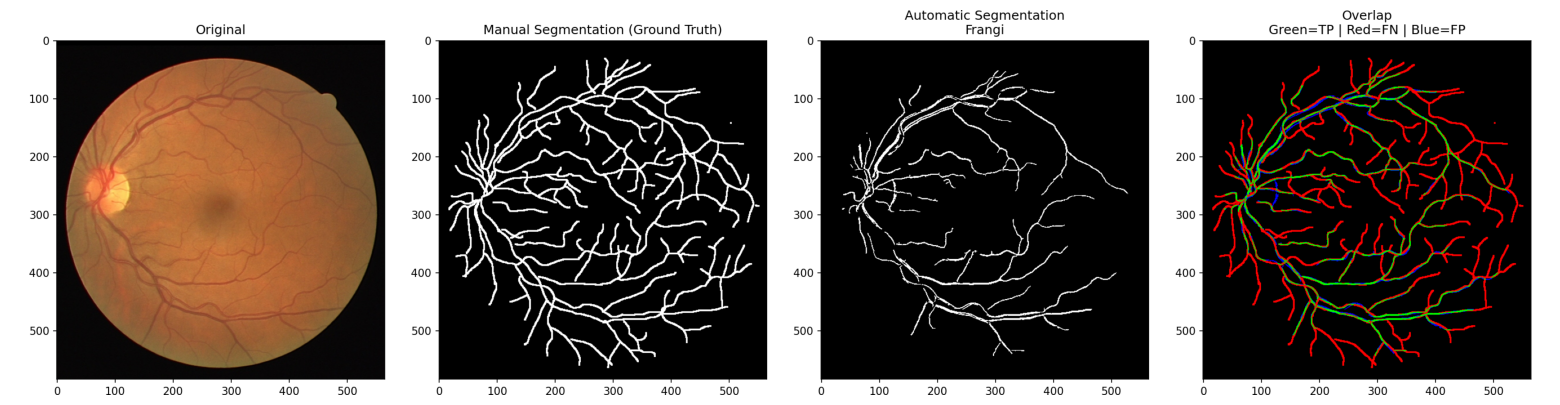

In [46]:
img = plt.imread('DRIVE/test/overlap_frangi/01_test.png')
plt.figure(figsize=(20, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

The overlap image shows mostly red pixels, meaning the Frangi filter misses a large portion of the vessels that were marked in the manual segmentation. Green pixels (correctly detected vessels) are visible mainly along the largest vessel branches. Blue pixels (false positives) are rare, which means the Frangi filter is conservative. Tt detects fewer vessels overall but what it does detect tends to be correct.

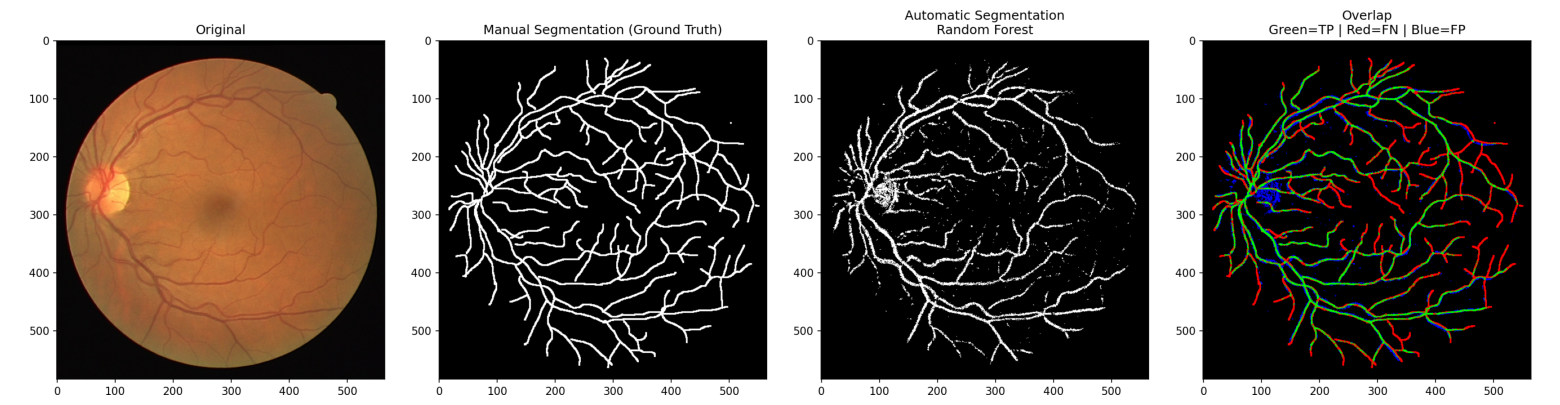

In [47]:
img = plt.imread('DRIVE/test/overlap_rf/01_test.png')
plt.figure(figsize=(20, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

The overlap image shows a more balanced mix of green and red pixels compared to Frangi, meaning the Random Forest detects more vessels correctly. However, a large blue region is visible around the optic disc, indicating that this bright area is falsely classified as vessel tissue. Red pixels are still present along the finer vessel branches, showing that thin capillaries remain difficult to detect even for the Random Forest.

## 6. Discussion
This section discusses the results of both methods, compares their strengths and weaknesses, describes the challenges encountered, and suggests directions for future improvement.

### 6.1 Results Summary

| Method        | Mean Dice | Std  | Mean Jaccard |
|---------------|-----------|------|--------------|
| Frangi Filter | 0.311     | ~0.11| 0.190        |
| Random Forest | 0.522     | ~0.03| 0.354        |

The evaluation on the 10 unseen test images shows a clear difference between the two methods. The Random Forest achieves a mean Dice score of 0.522 with a low standard deviation of 0.03, while the Frangi filter reaches only 0.306 with a much higher standard deviation of 0.117. This means the Random Forest not only performs better on average but is also considerably more consistent across different images. The Jaccard scores follow the same pattern, with the Random Forest (0.354) outperforming Frangi (0.186). Both methods are still well below the state-of-the-art performance of deep learning models on the same dataset, which typically exceed a Dice score of 0.80.

### 6.2 Frangi Filter
The Frangi filter is a classical, fully unsupervised method that requires no training data, making it fast and directly scalable to large datasets. It was specifically designed to detect tubular structures like blood vessels by analyzing local image curvature. However, it has clear limitations: it tends to miss fine capillaries and is sensitive to variations in illumination across images. This explains the high variability in scores. The method works reasonably well on high-contrast images but struggles considerably on darker or lower-contrast ones.

### 6.3 Random Forest
The Random Forest learns directly from the manual segmentations, which allows it to adapt to the specific appearance of vessels in this dataset. It uses multiple complementary features per pixel (raw intensity, Gaussian blur at different scales, Sobel edges, and the Frangi response) which together provide a richer description of each pixel than the Frangi filter alone. As a result, it detects both large and fine vessels more consistently across images. The main weakness is that it requires annotated training data, and with only 10 training images the model is still limited.

### 6.4 Challenges
Several challenges affected the results of both methods. The manual segmentations used as ground truth were created by a single non-expert annotator, which means they are not perfectly accurate. This directly limits how high the evaluation scores can realistically be. The optic disc, a bright circular region in the retina, was a recurring problem for both methods, as its high brightness causes it to be falsely detected as vessel tissue. Additionally, the strong class imbalance in the data, where the vast majority of pixels are background and only a small fraction are vessels, can bias classifiers towards predicting background more often. Another limitation concerns the preprocessing applied before segmentation. For the automatic methods, the images were preprocessed using the Python pipeline described in Section 3 (green channel extraction, CLAHE, normalization). For the manual segmentation in Fiji, the images were preprocessed manually (adjusting brightness and contrast by hand) which is a different and less reproducible process. This means that the manual and automatic segmentations were not produced from exactly the same preprocessed image, which introduces an additional source of inconsistency when comparing them during evaluation.

### 6. 5 Future Improvements
Several directions could improve the results in future work. The most straightforward improvement for the Random Forest would be to annotate more training images, which would reduce overfitting and improve generalization. A more advanced approach would be to train a U-Net, a deep learning architecture specifically designed for biomedical image segmentation, which would likely achieve Dice scores above 0.80 on this dataset. Post-processing steps such as morphological operations could also help refine the vessel boundaries and reduce false positives around the optic disc. Finally, data augmentation techniques such as rotating and flipping the training images could effectively increase the amount of training data without requiring additional manual annotation.

## 7. Use of Generative AI

Claude (Anthropic) was used as a generative AI tool during this project.

Specifically, Claude was used to:
- Help debug Python errors (e.g., missing imports, incorrect paths)
- Suggest and explain preprocessing steps (green channel extraction, CLAHE)
- Help implement the Frangi filter and Random Forest pipeline
- Explain concepts such as Dice score, Jaccard, CLAHE, and the Frangi filter
- improve and phrasing of written sections, making the text clearer and more natural to read

All code and text were reviewed and understood before inclusion. The author is able to explain all implementation decisions in their own words.

## 8. References
Breiman, L. (2001). Random Forests. Machine Learning, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324

Criminisi, A., Shotton, J., & Konukoglu, E. (2012). Decision Forests for Classiﬁcation, Regression, Density Estimation, Manifold Learning and Semi-Supervised Learning.

DRIVE - Grand Challenge. (n.d.). Grand-Challenge.Org. Retrieved May 28, 2026, from https://drive.grand-challenge.org/

Frangi, A. F., Niessen, W. J., Vincken, K. L., & Viergever, M. A. (1998). Multiscale vessel enhancement filtering. In W. M. Wells, A. Colchester, & S. Delp (Eds.), Medical Image Computing and Computer-Assisted Intervention—MICCAI’98 (pp. 130–137). Springer. https://doi.org/10.1007/BFb0056195

Lupascu, C. A., Tegolo, D., & Trucco, E. (2010). FABC: Retinal vessel segmentation using AdaBoost. IEEE Transactions on Information Technology in Biomedicine: A Publication of the IEEE Engineering in Medicine and Biology Society, 14(5), 1267–1274. https://doi.org/10.1109/TITB.2010.2052282

Orlando, J. I., Prokofyeva, E., & Blaschko, M. B. (2017). A Discriminatively Trained Fully Connected Conditional Random Field Model for Blood Vessel Segmentation in Fundus Images. IEEE Transactions on Bio-Medical Engineering, 64(1), 16–27. https://doi.org/10.1109/TBME.2016.2535311

Patton, N., Aslam, T. M., MacGillivray, T., Deary, I. J., Dhillon, B., Eikelboom, R. H., Yogesan, K., & Constable, I. J. (2006). Retinal image analysis: Concepts, applications and potential. Progress in Retinal and Eye Research, 25(1), 99–127. https://doi.org/10.1016/j.preteyeres.2005.07.001

Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional Networks for Biomedical Image Segmentation (arXiv:1505.04597). arXiv. https://doi.org/10.48550/arXiv.1505.04597

Teo, Z. L., Tham, Y.-C., Yu, M., Chee, M. L., Rim, T. H., Cheung, N., Bikbov, M. M., Wang, Y. X., Tang, Y., Lu, Y., Wong, I. Y., Ting, D. S. W., Tan, G. S. W., Jonas, J. B., Sabanayagam, C., Wong, T. Y., & Cheng, C.-Y. (2021). Global Prevalence of Diabetic Retinopathy and Projection of Burden through 2045: Systematic Review and Meta-analysis. Ophthalmology, 128(11), 1580–1591. https://doi.org/10.1016/j.ophtha.2021.04.027


